# Solving a discrete-time two-asset KMV-style HANK model with sequence-space Jacobians

- Author: Yuxuan Zhao
- Updated: 2026-08-23

This notebook solves a two-asset
Heterogeneous-Agent New Keynesian model based on the economic environment of
Kaplan, Moll, and Violante (2018). 

## 1) Model

Time is quarterly. A unit mass of households faces idiosyncratic labor-income
risk and trades a low-return liquid asset $b$ and a high-return illiquid asset
$a$. The illiquid account is subject to a transaction cost. Aggregate
production uses capital and labor, prices are sticky, monetary policy follows a
Taylor rule, and fiscal transfers close the government budget.

The aggregate exogenous paths are

$$
E=(\log Z,\eta),
$$

and the sequence-space unknown paths are

$$
U=(\pi,w,Y,K,q).
$$

For a horizon $T$, each symbol denotes the complete path from date $0$ through
$T-1$. The transition begins from the deterministic steady-state household
distribution and inherited capital, equity, and nominal interest rate. Beyond
$T-1$, continuation values and aggregate prices return to steady state.

### 1.1 Household state, timing, and preferences

At the beginning of date $t$, a household is in state

$$
s_t=(e_t,b_t,a_t),
$$

where $e_t$ is labor efficiency, $b_t$ is current liquid wealth, and $a_t\geq0$
is current illiquid wealth. It chooses

$$
c_t,\qquad n_t,\qquad b_{t+1},\qquad a_{t+1}.
$$

Preferences are

$$
\mathbb E_0\sum_{t=0}^{\infty}\beta^t
\left[
\frac{c_t^{1-\gamma}-1}{1-\gamma}
-\varphi\frac{n_t^{1+1/\nu}}{1+1/\nu}
\right],
$$

with the log-utility limit at $\gamma=1$. Idiosyncratic efficiency follows the
finite Markov chain

$$
\Pr(e_{t+1}=e'\mid e_t=e)=P_{ee'}.
$$

This earnings transition is the only exogenous movement across household
states. There is no death state.

### 1.2 Liquid and illiquid asset laws

Let $R_t^b$ and $R_t^a$ be gross real returns. Borrowers pay the wedge
$\kappa_b$:

$$
R_t^b(b_t)=R_t^b+\kappa_b\mathbf 1\{b_t<0\}.
$$

Define the active quarterly deposit into the illiquid account as

$$
D_t=a_{t+1}-R_t^aa_t.
$$

For a quarterly period of length $\Delta=1/4$, the transaction cost is

$$
\Psi_\Delta(D_t,a_t)
=\chi_0|D_t|
+\frac{\chi_1}{\chi_2}\Delta^{1-\chi_2}
\left|\frac{D_t}{\max(a_t,\underline a)}\right|^{\chi_2}
\max(a_t,\underline a).
$$

The period budget constraint is

$$
c_t+b_{t+1}+a_{t+1}+\Psi_t
=R_t^b(b_t)b_t+R_t^aa_t+(1-\tau_t)w_te_tn_t+T_t,
$$

subject to

$$
b_{t+1}\geq\underline b,\qquad a_{t+1}\geq0,
\qquad c_t>0,\qquad 0\leq n_t\leq1.
$$

Only the absolute value at the transaction-cost kink is smoothed numerically:
$|D|_\epsilon=\sqrt{D^2+\epsilon^2}$.

### 1.3 Recursive household problem

Given an aggregate path, the household solves

$$
V_t(e,b,a)=\max_{c,n,b',a'}
\left\{
u(c,n)+\beta\sum_{e'}P_{ee'}V_{t+1}(e',b',a')
\right\}
$$

subject to the budget and portfolio constraints above. There is no survival
factor multiplying continuation value. The distribution evolves only through
the policy functions and the earnings transition:

$$
D_{t+1}=\mathcal T(g_t^b,g_t^a,P)D_t.
$$

Away from constraints and the transaction-cost kink, the liquid Euler equation
is

$$
u_c(c_t,n_t)=\beta\mathbb E_t
\left[R_{t+1}^b(b_{t+1})u_c(c_{t+1},n_{t+1})\right].
$$

The illiquid first-order condition is

$$
\frac{W_t^a(e,b',a')}{W_t^b(e,b',a')}
=1+\Psi_1(a',a;R_t^a),
\qquad
W_t^j=\beta\mathbb E_t[V_{j,t+1}].
$$

At $b'=\underline b$, a Kuhn-Tucker multiplier defines a separate constrained
branch.

### 1.4 Competitive final-good producer

A competitive final-good producer combines a continuum of differentiated
intermediate goods with the CES technology

$$
Y_t=\left[\int_0^1 y_{j,t}^{\frac{\epsilon-1}{\epsilon}}dj
\right]^{\frac{\epsilon}{\epsilon-1}},
\qquad \epsilon>1.
$$

Taking the final-good price $P_t$ as the numeraire, the producer minimizes
the cost of delivering $Y_t$:

$$
\min_{\{y_{j,t}\}}\int_0^1p_{j,t}y_{j,t}dj
\quad\text{s.t. the CES aggregator above}.
$$

The first-order conditions give the price index and the demand curve facing
intermediate producer $j$:

$$
P_t=\left[\int_0^1p_{j,t}^{1-\epsilon}dj\right]^{\frac{1}{1-\epsilon}},
\qquad
y_{j,t}=\left(\frac{p_{j,t}}{P_t}\right)^{-\epsilon}Y_t.
$$

Thus each intermediate firm has market power: changing its relative price
$p_{j,t}/P_t$ changes the quantity demanded of its variety.

### 1.5 Intermediate firms: technology, factor demand, and current profit

Firm $j$ uses capital installed at the end of the previous quarter and current
labor to produce

$$
y_{j,t}=Z_tK_{j,t-1}^{\alpha}N_{j,t}^{1-\alpha}.
$$

In a symmetric equilibrium, all firms choose the same price and input bundle.
Price dispersion therefore vanishes at the expansion point and aggregate
production is

$$
Y_t=Z_tK_{t-1}^{\alpha}(N_t^f)^{1-\alpha},
\qquad
N_t^f=\left(\frac{Y_t}{Z_tK_{t-1}^{\alpha}}\right)^{\frac{1}{1-\alpha}}.
$$

Let $mc_t$ denote real marginal cost. Conditional factor demand gives

$$
w_t=(1-\alpha)mc_t\frac{Y_t}{N_t^f},
\qquad
r_t^k=\alpha mc_t\frac{Y_t}{K_{t-1}}.
$$

Equivalently, the macro block recovers marginal cost from candidate paths as

$$
mc_t=\frac{w_tN_t^f}{(1-\alpha)Y_t}.
$$

Firm $j$ pays a Rotemberg resource cost when it changes its price. Its current
real profit is

$$
\mathcal D_{j,t}=\left[
\left(\frac{p_{j,t}}{P_t}\right)^{1-\epsilon}
-mc_t\left(\frac{p_{j,t}}{P_t}\right)^{-\epsilon}
-\frac{\theta_p}{2}
\left(\frac{p_{j,t}}{p_{j,t-1}}-1\right)^2
\right]Y_t.
$$

The three terms are revenue, variable production cost, and the real resource
cost of changing the price. Define net inflation by
$\pi_t=P_t/P_{t-1}-1$. Under symmetry, aggregate adjustment costs and current
profit become

$$
\Theta_t^p=\frac{\theta_p}{2}\pi_t^2Y_t,
\qquad
\mathcal D_t=(1-mc_t)Y_t-\Theta_t^p.
$$

These adjustment costs are not transfers between agents: they absorb final
goods and therefore also appear in goods-market clearing.

### 1.6 Dynamic price setting and the New Keynesian Phillips curve

The intermediate firm inherits $p_{j,t-1}$ and chooses $p_{j,t}$ while taking
the complete aggregate transition path as given. Its recursive pricing problem is

$$
\mathcal W_t(p_{j,t-1})
=\max_{p_{j,t}}\left\{\mathcal D_{j,t}
+\beta\mathcal W_{t+1}(p_{j,t})\right\},
\qquad \mathcal W_T=\mathcal W_{ss}.
$$

The chosen price affects current demand and current adjustment costs. It also
becomes next quarter's inherited price, so the pricing condition is forward
looking. Differentiating the problem, applying the envelope theorem, and only
then imposing symmetry gives the nonlinear Rotemberg condition

$$
0=(1-\epsilon)+\epsilon mc_t
-\theta_p\pi_t(1+\pi_t)
+\beta\frac{Y_{t+1}}{Y_t}
\theta_p\pi_{t+1}(1+\pi_{t+1}).
$$

Around the zero-inflation steady state, the code uses the following stable local
discrete-time representation of that first-order condition:

$$
\boxed{
H_t^{NKPC}
=\log(1+\pi_t)
-\beta\frac{Y_{t+1}}{Y_t}\log(1+\pi_{t+1})
-\kappa_p(mc_t-\bar{mc})=0.
}
$$

Here $\bar{mc}$ is steady-state marginal cost and $\kappa_p$ is the local
Phillips-curve slope. Higher marginal cost makes firms want to raise prices,
whereas a larger Rotemberg cost makes inflation respond more slowly. At the
terminal date, $Y_T=\bar Y$ and $\pi_T=0$.

### 1.7 Capital accumulation, the illiquid return, and equity valuation

One unit of the final good can be converted into one unit of installed capital.
Capital therefore evolves according to

$$
K_t=(1-\delta)K_{t-1}+I_t,
\qquad
I_t=K_t-(1-\delta)K_{t-1}.
$$

Capital carried into date $t$ pays its rental income plus the undepreciated
capital stock. Its gross return is

$$
R_t^a=1+r_t^k-\delta.
$$

The household's illiquid account contains both physical capital and a unit
supply of firm equity. Let $q_{t-1}$ be the beginning-of-period market value of
equity. During date $t$, equity pays current profit $\mathcal D_t$ and then
trades ex dividend at $q_t$. Its realized gross return is therefore

$$
R_t^q=\frac{\mathcal D_t+q_t}{q_{t-1}}.
$$

Because capital and equity are held inside the same illiquid account, no
arbitrage requires $R_t^q=R_t^a$. The corresponding residual is

$$
\boxed{
H_t^{equity}
=R_t^aq_{t-1}-\mathcal D_t-q_t=0.
}
$$

Thus $H^{equity}$ is not another market-clearing condition. It is the dynamic
asset-pricing condition that makes equity deliver the same return as physical
capital. Equivalently, it recursively values equity as the discounted stream of
future profits.

### 1.8 Monetary and fiscal policy

The nominal policy rate follows

$$
i_t-\bar i
=\rho_i(i_{t-1}-\bar i)+(1-\rho_i)\phi_\pi\pi_t+\eta_t.
$$

A liquid bond purchased at date $t-1$ pays $1+i_{t-1}$ nominal units at date
$t$. Hence its realized gross real return is

$$
R_t^b=\frac{1+i_{t-1}}{1+\pi_t}.
$$

This timing is important: the current monetary innovation changes $i_t$ and
therefore directly enters $R_{t+1}^b$, while current inflation revalues the
nominal payoff inherited from the previous quarter.

Government debt $\bar B$, purchases $G$, and the labor-income tax rate $\tau$
are fixed. Lump-sum transfers balance the period government budget:

$$
T_t=\tau w_tN_t^f-G-(R_t^b-1)\bar B.
$$

A monetary expansion can therefore affect households indirectly through both
labor income and the fiscal savings generated by lower debt-service costs.

### 1.9 Recursive equilibrium, market clearing, and residuals

Given the beginning-of-date distribution $D_t(e,b,a)$ and household policies,
define

$$
\begin{aligned}
B_t^h&=\int g_t^b(e,b,a)\,dD_t,
&A_t^h&=\int g_t^a(e,b,a)\,dD_t,\\
C_t&=\int c_t(e,b,a)\,dD_t,
&N_t^h&=\int e n_t(e,b,a)\,dD_t.
\end{aligned}
$$

$B_t^h$ and $A_t^h$ are the end-of-date positions $b_{t+1}$ and $a_{t+1}$
chosen at date $t$; the code indexes them by their decision date. The three
market-clearing conditions are

$$
\boxed{
B_t^h=\bar B,
\qquad
A_t^h=K_t+q_t,
\qquad
N_t^h=N_t^f.
}
$$

The first equation clears the liquid government-bond market. The second clears
the illiquid asset market: household illiquid wealth finances installed capital
and the market value of the unit equity claim. The third equates efficiency units
of labor supplied by households with labor demanded by firms.

For the unknown paths $U=(\pi,w,Y,K,q)$ and exogenous paths
$E=(\log Z,\eta)$, the outer solver uses exactly five residuals:

$$
\begin{aligned}
H_t^{NKPC}&=\log(1+\pi_t)
-\beta\frac{Y_{t+1}}{Y_t}\log(1+\pi_{t+1})
-\kappa_p(mc_t-\bar{mc}),\\
H_t^B&=B_t^h-\bar B,\\
H_t^A&=A_t^h-K_t-q_t,\\
H_t^N&=N_t^h-N_t^f,\\
H_t^{equity}&=R_t^aq_{t-1}-\mathcal D_t-q_t.
\end{aligned}
$$

Stacking all dates by residual block gives

$$
H(U;E)=
\begin{bmatrix}
H^{NKPC}\\H^B\\H^A\\H^N\\H^{equity}
\end{bmatrix}
\in\mathbb R^{5T},
\qquad H(U;E)=0.
$$

Finally, define aggregate household portfolio costs and borrowing-service costs
as

$$
\Chi_t=\int\Psi_t\,dD_t,
\qquad
\mathcal S_t^b=\kappa_b\int[-b]_+\,dD_t.
$$

Goods-market clearing is

$$
H_t^G
=Y_t-C_t-I_t-G-\Theta_t^p-\Chi_t-\mathcal S_t^b=0.
$$

It is retained as an independent Walras-law diagnostic rather than a sixth
solver target. When household budgets, the government budget, the three markets,
and equity pricing are all implemented consistently, $H_t^G$ must also be zero.

## 2) Julia Setup

The setup cell locates the repository root, activates the pinned Julia project,
loads plotting and linear-algebra tools, and includes `src/SSJ_Function.jl`.
All economic and numerical functions remain in the source file; the notebook
only defines the model, sets parameters, calls blocks, and displays results.

In [1]:
using Pkg
project_root = isfile(joinpath(pwd(), "Project.toml")) ? pwd() : normpath(joinpath(pwd(), ".."))
Pkg.activate(project_root)
using LinearAlgebra, Plots, Printf
include(joinpath(project_root, "src", "SSJ_Function.jl"))
using .KMVDiscrete
default(size=(680, 380), linewidth=2, legend=:best)

  Activating project at `C:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\Research\sequence_space_jacobian`


## 3) Transition Blocks and DAG

For a finite horizon $T$, stack the unknown and exogenous sequences as

$$
U=(\pi,w,Y,K,q)\in\mathbb R^{5T},
\qquad
E=(\log Z,\eta)\in\mathbb R^{2T}.
$$

For a given $E$, the outer solver proposes $U$. One evaluation of the general-
equilibrium map then passes through five blocks. The first four construct the
paths needed by households and firms; the final block evaluates every equilibrium
condition. In particular, the NKPC and the equity-pricing equation belong to the
residual block rather than to separate computational blocks.

### 3.1 Monetary and Fisher block

Given the inflation path and the monetary innovation, this block
recursively constructs the nominal policy rate and then converts it into the realized
gross return on a one-period liquid bond:

$$
i_t=\bar i+\rho_i(i_{t-1}-\bar i)+(1-\rho_i)\phi_\pi\pi_t+\eta_t,
\qquad
R_t^b=\frac{1+i_{t-1}}{1+\pi_t}.
$$

**Input:** $(\pi,\eta)$ and $i_{-1}=\bar i$.  
**Output:** $(i,R^b)$.

This is a forward recursion followed by an algebraic Fisher mapping; it does not
require a root solve. The lag in the Fisher equation preserves the timing of the
one-period bond bought in the preceding quarter.

### 3.2 Fiscal block

The government budget determines the lump-sum transfer path
after taxes, purchases, and interest payments on government debt have been paid:

$$
T_t=\tau w_tN_t^f-G-(R_t^b-1)\bar B.
$$

**Input:** $(w,N^f,R^b)$ and fixed $(\tau,G,\bar B)$.  
**Output:** $T$.

This block is static conditional on its input paths. Keeping it explicit makes the
fiscal interest-saving channel transparent: a change in $R^b$ changes debt service
and therefore household transfers.

### 3.3 Firm block

Conditional on the candidate paths $(Y,K,w,\pi)$ and TFP, the
firm block inverts the production function to obtain labor demand and then computes
the factor prices, investment, price-adjustment cost, and dividend flow implied by
those paths. With $Z_t=\bar Z\exp(\log Z_t)$ and inherited $K_{t-1}$,

$$
N_t^f=\left(\frac{Y_t}{Z_tK_{t-1}^{\alpha}}\right)^{1/(1-\alpha)},
\qquad
mc_t=\frac{w_tN_t^f}{(1-\alpha)Y_t},
$$

$$
r_t^k=\frac{\alpha mc_tY_t}{K_{t-1}},
\qquad
R_t^a=1+r_t^k-\delta,
\qquad
I_t=K_t-(1-\delta)K_{t-1},
$$

$$
\Theta_t^p=\frac{\theta_p}{2}\pi_t^2Y_t,
\qquad
\mathcal D_t=(1-mc_t)Y_t-\Theta_t^p.
$$

**Input:** $(Y,K,w,\pi,\log Z)$ and $K_{-1}=\bar K$.  
**Output:** $(Z,N^f,mc,r^k,R^a,I,\Theta^p,\mathcal D)$.

This block does **not** impose optimal price setting or equity pricing. It only
computes firm quantities and cash flows conditional on the proposed paths; the NKPC
and equity-pricing equations are checked together in the residual block below.

### 3.4 Two-asset household transition block

Given complete price and transfer paths, the block solves the
recursive household problem

$$
V_t(e,b,a)=\max_{c,n,b',a'}\left\{u(c,n)+\beta
\sum_{e'}P_{ee'}V_{t+1}(e',b',a')\right\},
$$

subject to the two-asset budget constraint and borrowing constraints in Section 1.
Starting from $(V_{b,T},V_{a,T})=(V_{b,ss},V_{a,ss})$, backward two-asset EGM
constructs $(c_t,n_t,b'_{t},a'_{t})$ at every date. Starting from $D_0=D_{ss}$,
the induced transition lotteries and the earnings matrix propagate the distribution:

$$
D_{t+1}=\mathcal T(g_t^b,g_t^a,P)D_t.
$$

The date-$t$ policies are then integrated against $D_t$.

**Input:** $(R^b,R^a,w,\tau,T)$, terminal marginal values, and $D_0$.  
**Output:** $(B,A,C,H,N,\Chi)$ and the terminal distribution $D_T$.

Thus the household block is one sequence-to-sequence transition map, not a collection
of independent static choices. No survival probability, newborn distribution, or
annuity-return adjustment enters this discrete-time version.

### 3.5 Equilibrium residual block

This final block takes the proposed aggregate paths and the outputs
of the firm and household blocks and asks whether they constitute an equilibrium. It
evaluates the dynamic pricing equation, three market-clearing conditions, and the
equity-pricing equation:

$$
H_t^{NKPC}=\log(1+\pi_t)-\beta\frac{Y_{t+1}}{Y_t}
\log(1+\pi_{t+1})-\kappa_p(mc_t-\bar{mc}),
$$

$$
H_t^B=B_t-\bar B,
\qquad
H_t^A=A_t-K_t-q_t,
\qquad
H_t^N=N_t-N_t^f,
$$

$$
H_t^{equity}=R_t^aq_{t-1}-(\mathcal D_t+q_t).
$$

**Input:** $(\pi,Y,K,q)$, firm outputs, and household aggregates.  
**Output:**

$$
H(U;E)=\left[H^{NKPC};H^B;H^A;H^N;H^{equity}\right]
\in\mathbb R^{5T}.
$$

The outer solver changes $U=(\pi,w,Y,K,q)$ until $H(U;E)=0$. The goods-market
residual

$$
H_t^G=Y_t-C_t-I_t-G-\Theta_t^p-\Chi_t-\mathcal S_t^b
$$

is retained as an independent Walras-law diagnostic, not as a sixth target.

### Initial and terminal conditions

The transition starts from

$$
D_0=D_{ss},\qquad K_{-1}=K_{ss},\qquad q_{-1}=q_{ss},
\qquad i_{-1}=i_{ss}.
$$

Household continuation marginal values and the NKPC terminal leads are evaluated
at the deterministic steady state. No restriction is imposed on $D_T$.

The table below is the compact interface specification; the diagram visualizes
the same dependency structure.

In [2]:
block_interfaces = kmv_block_table()
block_interfaces

5-element Vector{@NamedTuple{block::String, inputs::String, outputs::String}}:
 (block = "Monetary + Fisher", inputs = "pi, eta; inherited i[-1]", outputs = "nominal rate i, liquid return Rb")
 (block = "Fiscal", inputs = "w,Nf,Rb; fixed tau,G,Bbar", outputs = "lump-sum transfer T")
 (block = "Firm", inputs = "Y,K,w,pi,log Z; inherited K[-1]", outputs = "Nf, mc, rk, Ra, I, price cost, profit")
 (block = "Two-asset household transition", inputs = "Rb,Ra,w,tau,T; terminal Vb,Va; initial D", outputs = "B,A,C,H,N,CHI; terminal D")
 (block = "Equilibrium residuals", inputs = "pi,Y,K,q; firm and household outputs", outputs = "NKPC, liquid, illiquid, labor, equity; goods diagnostic")

In [3]:
display(Base.HTML(kmv_discrete_dag_svg()))

HTML{String}("<svg xmlns='http://www.w3.org/2000/svg' width='980' height='800' viewBox='0 0 980 800'>\n  <defs>\n    <marker id='kmvd_arrow' markerWidth='10' markerHeight='10' refX='8' refY='3' orient='auto' markerUnits='strokeWidth'>\n      <path d='M0,0 L0,6 L9,3 z' fill='#333333'/>\n    </marker>\n    <style>\n      .node { fill: #ffffff; stroke: #2f3b52; stroke-width: 1.8; }\n      .box { rx: 8; ry: 8; }\n      .label { font-family: Georgia, serif; font-size: 17px; fill: #111827; text-anchor: middle; dominant-baseline: middle; }\n      .small { font-family: Georgia, serif; font-size: 13px; fill: #374151; text-anchor: middle; }\n      .edge { stroke: #333333; stroke-width: 1.7; fill: none; marker-end: url(#kmvd_arrow); }\n      .tag { font-family: Georgia, serif; font-size: 12px; fill: #111827; text-anchor: middle; }\n    </style>\n  </defs>\n\n  <rect x='45' y='28' width='180' height='68' class='node box'/>\n  <text x='135' y='53' class='label'>Exogenous paths</text>\n  <text x='135' y='79' class='small'>log Z, eta</text>\n\n  <rect x='755' y='28' width='180' height='68' class='node box'/>\n  <text x='845' y='53' class='label'>Unknown paths</text>\n  <text x='845' y='79' class='small'>pi, w, Y, K, q</text>\n\n  <ellipse cx='225' cy='185' rx='135' ry='46' class='node'/>\n  <text x='225' y='176' class='label'>monetary + Fisher</text>\n  <text x='225' y='204' class='small'>(pi, eta) -&gt; (i, Rb)</text>\n\n  <ellipse cx='700' cy='185' rx='165' ry='48' class='node'/>\n  <text x='700' y='174' class='label'>firm</text>\n  <text x='700' y='202' class='small'>(Y, K, w, pi, Z) -&gt; (Nf, mc, Ra, I, profit)</text>\n\n  <ellipse cx='180' cy='330' rx='100' ry='42' class='node'/>\n  <text x='180' y='322' class='label'>fiscal</text>\n  <text x='180' y='347' class='small'>(w, Nf, Rb) -&gt; T</text>\n\n  <ellipse cx='500' cy='400' rx='215' ry='54' class='node'/>\n  <text x='500' y='390' class='label'>two-asset household transition</text>\n  <text x='500' y='420' class='small'>(Rb, Ra, w, tau, T) -&gt; (B, A, C, Nh, Chi)</text>\n\n  <ellipse cx='500' cy='595' rx='255' ry='62' class='node'/>\n  <text x='500' y='575' class='label'>equilibrium residuals</text>\n  <text x='500' y='603' class='small'>H_NKPC, B - Bbar, A - K - q, Nh - Nf, H_equity</text>\n  <text x='500' y='629' class='small'>goods market returned as a diagnostic</text>\n\n  <polygon points='500,690 640,732 500,774 360,732' class='node'/>\n  <text x='500' y='732' class='label'>H(U; E) = 0</text>\n\n  <path d='M145 96 C155 120,180 143,197 147' class='edge'/>\n\n  <path d='M205 96 C330 112,500 137,564 163' class='edge'/>\n\n  <path d='M785 96 C665 116,430 133,352 166' class='edge'/>\n\n  <path d='M845 96 C820 120,785 145,775 150' class='edge'/>\n\n  <path d='M225 231 L190 287' class='edge'/>\n\n  <path d='M289 223 C330 286,365 344,389 371' class='edge'/>\n\n  <path d='M558 213 C430 240,302 287,271 313' class='edge'/>\n\n  <path d='M627 229 C594 278,557 327,534 348' class='edge'/>\n\n  <path d='M275 345 C320 362,348 378,372 389' class='edge'/>\n\n  <path d='M500 454 L500 531' class='edge'/>\n\n  <path d='M790 220 C883 350,812 524,735 565' class='edge'/>\n\n  <path d='M890 96 C966 265,932 493,752 582' class='edge'/>\n\n  <path d='M500 657 L500 688' class='edge'/>\n</svg>\n")

## 4) Calibration and State Grids

This reorganization leaves the existing provisional calibration unchanged.
The parameters combine KMV-style preferences and transaction-cost curvature
with a quarterly discrete earnings approximation and a no-death steady state.
They should be interpreted as a computational baseline, not as a converted
replication of KMV's continuous-time calibration.

The household state grid is three-dimensional:

$$
(e,b,a)\in\mathcal E\times\mathcal B\times\mathcal A.
$$

The liquid grid contains the borrowing limit and an explicit zero, and is dense
near both. The illiquid grid is dense near $a=0$, where transaction-cost and
portfolio policies are most nonlinear. The multiplier grid is used to solve the
borrowing-constrained branch.

In [4]:
params = KMVDiscreteParams(
    beta=0.98132, gamma=1.0, frisch=1.0, phi_n=2.0, tau=0.30,
    chi0=0.0438, chi1=0.30, chi2=1.402, period_years=0.25,
    borrowing_wedge=0.015, bmin=-0.65, bmax=50.0, amax=80.0,
    nB=25, nA=31, nE=5, nKappa=25, rho_e=0.966, sigma_e=0.92
)
macro_params = KMVMacroParams(Y=1.0, delta=0.02, theta_p=100.0,
                               kappa_p=0.08, phi_pi=1.5, rho_i=0.0)
grids = make_kmv_grids(params)
(liquid_points=length(grids.b), illiquid_points=length(grids.a),
 earnings_states=length(grids.e), mass=sum(grids.ed))

(liquid_points = 25, illiquid_points = 31, earnings_states = 5, mass = 1.0)

### 4.1 Numerical grids

The figures show the actual grid nodes used by the baseline household solver.
The upper bounds are numerical safeguards; the policy and distribution checks
below verify that they do not determine the reported solution.

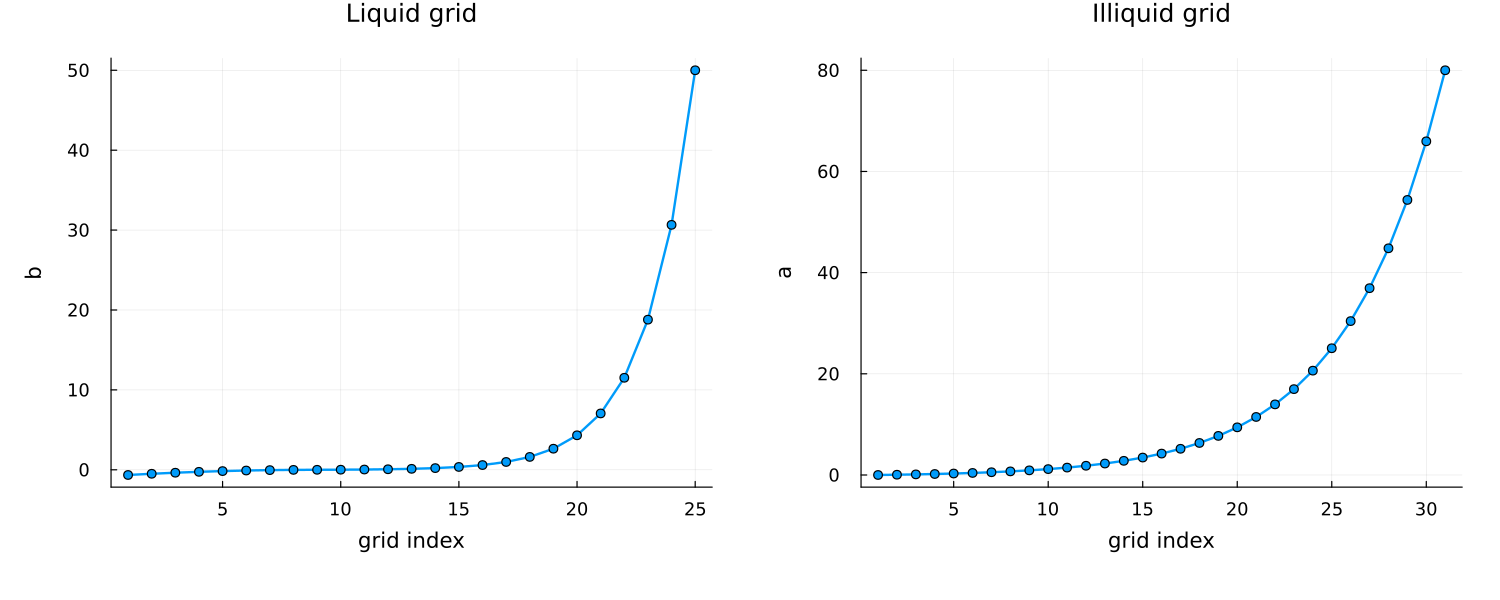

In [5]:
p1 = plot(grids.b, marker=:circle, xlabel="grid index", ylabel="b", title="Liquid grid", legend=false)
p2 = plot(grids.a, marker=:circle, xlabel="grid index", ylabel="a", title="Illiquid grid", legend=false)
plot(p1, p2, layout=(1,2), size=(1250,500), dpi=120,
     left_margin=10Plots.mm, right_margin=6Plots.mm,
     bottom_margin=15Plots.mm, top_margin=7Plots.mm,
     guidefontsize=12, tickfontsize=10, titlefontsize=14)

## 5) Solve the Household Problem by Two-Asset EGM

The household is the heterogeneous block. `src/SSJ_Function.jl` implements its
backward and forward operations; this section states exactly what those
functions compute.

### 5.1 Backward continuation objects

Given next-period marginal values $(V_{b,t+1},V_{a,t+1})$, form

$$
W_t^b(e,b',a')=\beta\sum_{e'}P_{ee'}V_{b,t+1}(e',b',a'),
$$

$$
W_t^a(e,b',a')=\beta\sum_{e'}P_{ee'}V_{a,t+1}(e',b',a').
$$

For each current $(e,a)$ and proposed liquid choice $b'$, solve the illiquid
first-order condition

$$
\frac{W_t^a(e,b',a')}{W_t^b(e,b',a')}
=1+\Psi_1(a',a;R_t^a)
$$

for $a'$. Conditional on $(b',a')$, the liquid Euler equality gives

$$
c_t=(W_t^b)^{-1/\gamma},
$$

and the intratemporal labor condition determines $n_t$.

### 5.2 Endogenous current-liquid grid

Substitute $(c,n,b',a')$ into the budget constraint and invert the current
liquid return schedule. This produces the endogenous current-liquid position

$$
b^{endo}(e,b',a).
$$

Interpolation maps $(b',a')$ from the endogenous grid back to the fixed
$b$ grid for each $(e,a)$.

### 5.3 Borrowing-constrained branch

When the unconstrained solution implies $b'<\underline b$, set

$$
b'=\underline b
$$

and solve the illiquid condition jointly with a nonnegative Kuhn-Tucker
multiplier. The constrained and unconstrained branches are spliced at the
endogenous cutoff. Policies are clipped only at the numerical upper bounds.

### 5.4 Stationary backward and forward fixed points

At stationary prices, iterate the backward map until $(V_b,V_a)$ converge.
Holding the converged policies fixed, iterate

$$
D'=\mathcal T(g^b,g^a,P)D
$$

until the invariant distribution converges. Bilinear lottery weights on the
$(b,a)$ grids preserve probability mass. Aggregation then gives

$$
(B,A,C,H,N,\Chi).
$$

The complete stationary household interface is therefore

$$
(R^b,R^a,w,\tau,T;\text{grids, parameters})
\longmapsto
(g^b,g^a,c,n,V_b,V_a,D,B,A,C,H,N,\Chi).
$$

## 6) Deterministic Steady State

The baseline call first solves the stationary household problem at the supplied
steady prices. The macro closure then selects production objects so that
capital and equity earn the common illiquid return and

$$
A=K+q.
$$

The steady state is the expansion point for every household and general-
equilibrium sequence-space derivative below.

In [6]:
ss = calibrate_kmv_steady_state(params, macro_params;
                                Rb=1.005, Ra=1.01425, w=1.05, T=0.10,
                                backward_tol=6e-6, forward_tol=5e-9, damp=0.8)
h = ss.household
m = ss.macro_ss
(backward_iterations=h.backward_iterations, backward_error=h.backward_error,
 forward_iterations=h.forward_iterations, forward_error=h.forward_error)

(backward_iterations = 859, backward_error = 5.982310699037541e-6, forward_iterations = 1179, forward_error = 4.962581168915792e-9)

### 6.1 Steady-state moments and macro closure

The table separates household aggregates from macro objects. The equity
residual checks no-arbitrage; the goods residual checks the aggregate resource
constraint independently of the targeted markets.

In [7]:
steady_moments = [
    (moment="liquid wealth B", value=h.B),
    (moment="illiquid wealth A", value=h.A),
    (moment="consumption C", value=h.C),
    (moment="mean hours H", value=h.H),
    (moment="efficiency labor N", value=h.N),
    (moment="share b < 0", value=h.negative_b),
    (moment="capital K", value=m.K),
    (moment="equity q", value=m.q),
    (moment="capital share alpha", value=m.alpha),
    (moment="marginal cost mc", value=m.mc),
    (moment="equity residual", value=m.equity_residual),
    (moment="goods residual", value=m.goods_residual)
]
steady_moments

12-element Vector{@NamedTuple{moment::String, value::Float64}}:
 (moment = "liquid wealth B", value = 1.196522332056122)
 (moment = "illiquid wealth A", value = 12.254337218808192)
 (moment = "consumption C", value = 0.7070482627015688)
 (moment = "mean hours H", value = 0.4821169176892518)
 (moment = "efficiency labor N", value = 0.6247366426336294)
 (moment = "share b < 0", value = 0.5534646635346276)
 (moment = "capital K", value = 8.470110993333558)
 (moment = "equity q", value = 3.784226225474635)
 (moment = "capital share alpha", value = 0.30663675725530043)
 (moment = "marginal cost mc", value = 0.946074776286986)
 (moment = "equity residual", value = -9.71445146547012e-17)
 (moment = "goods residual", value = -9.630249372394317e-7)

### 6.2 Provisional calibration targets

These comparisons retain the existing tutorial targets in units where
quarterly output is one. They document the current expansion point; they are
not presented as a quantitative replication of KMV's continuous-time table.

In [8]:
calibration_comparison = [
    (moment="liquid wealth", model=h.B, approximate_target=1.04, gap=h.B-1.04),
    (moment="illiquid wealth", model=h.A, approximate_target=11.68, gap=h.A-11.68),
    (moment="mean hours", model=h.H, approximate_target=0.50, gap=h.H-0.50)
]
calibration_comparison

3-element Vector{@NamedTuple{moment::String, model::Float64, approximate_target::Float64, gap::Float64}}:
 (moment = "liquid wealth", model = 1.196522332056122, approximate_target = 1.04, gap = 0.15652233205612198)
 (moment = "illiquid wealth", model = 12.254337218808192, approximate_target = 11.68, gap = 0.5743372188081928)
 (moment = "mean hours", model = 0.4821169176892518, approximate_target = 0.5, gap = -0.0178830823107482)

### 6.3 Household policy functions

All horizontal axes are **current** state variables.

- **Consumption:** $c_t(b_t\mid e_t,a_t)$ over the low and middle liquid-wealth
  region.
- **Liquid policy:** $b_{t+1}(b_t\mid e_t,a_t)$ for several current illiquid
  positions. The 45-degree line identifies an unchanged liquid stock.
- **Illiquid policy:** $a_{t+1}(b_t\mid e_t,a_t)$ for the same current illiquid
  positions. Its horizontal axis is current liquid wealth so that the portfolio
  adjustment kink near $b_t=0$ is visible.

The third panel has no 45-degree line because its horizontal and vertical axes
are different assets. Active illiquid deposits are

$$
D_t=a_{t+1}-R^aa_t.
$$

Plotting $a_{t+1}$ displays the actual state transition; subtracting $R^aa_t$
would magnify the transaction-cost kink. The liquid panel focuses on
$b_t\in[\underline b,5]$, while the illiquid panel extends to
$b_t\in[\underline b,15]$.

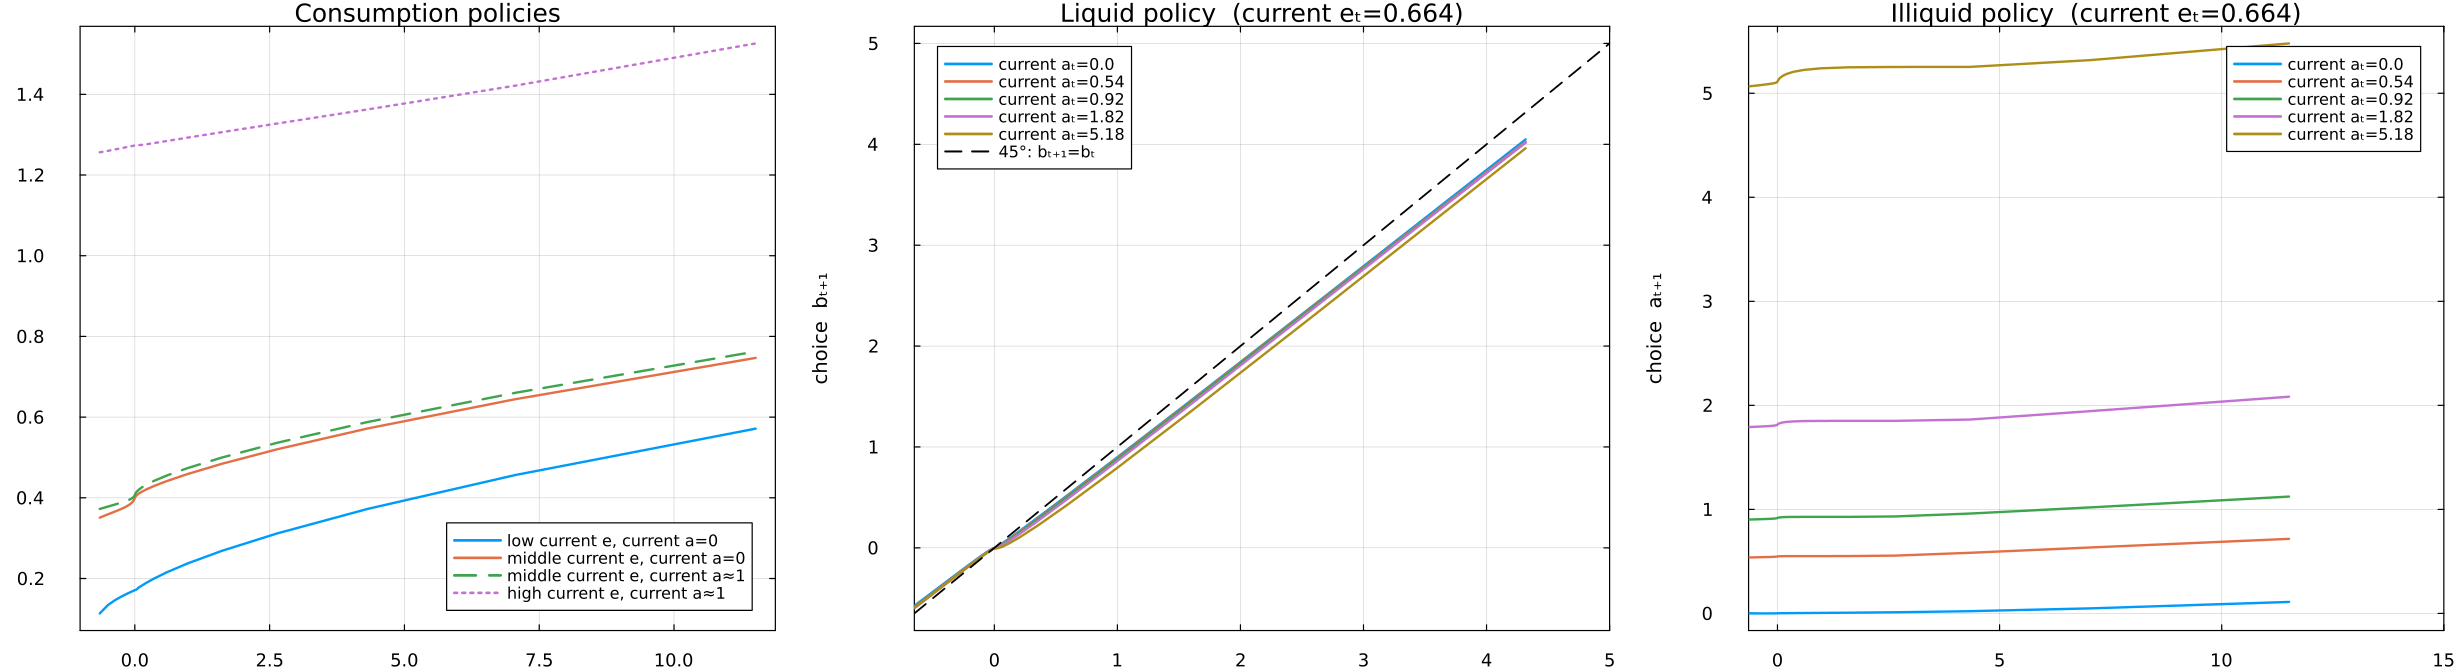

In [9]:
iz_low, iz_mid, iz_high = 1, cld(length(grids.e),2), length(grids.e)
ia_zero = 1
ia_one = argmin(abs.(grids.a .- 1.0))
current_e = round(grids.e[iz_mid], digits=3)
b_plot_consumption = findall(grids.b .<= 15.0)
b_plot_liquid = findall(grids.b .<= 5.0)
b_plot_illiquid = findall(grids.b .<= 15.0)
p_c = plot(grids.b[b_plot_consumption], h.c[iz_low,b_plot_consumption,ia_zero], label="low current e, current a=0", xlabel="current liquid wealth  bₜ", ylabel="current consumption  cₜ", title="Consumption policies")
plot!(p_c, grids.b[b_plot_consumption], h.c[iz_mid,b_plot_consumption,ia_zero], label="middle current e, current a=0")
plot!(p_c, grids.b[b_plot_consumption], h.c[iz_mid,b_plot_consumption,ia_one], label="middle current e, current a≈1", linestyle=:dash)
plot!(p_c, grids.b[b_plot_consumption], h.c[iz_high,b_plot_consumption,ia_one], label="high current e, current a≈1", linestyle=:dot)
a_targets = [0.0, 0.5, 1.0, 2.0, 5.0]
a_indices = unique([argmin(abs.(grids.a .- value)) for value in a_targets])
p_bp = plot(xlabel="current liquid wealth  bₜ", ylabel="choice  bₜ₊₁", title="Liquid policy  (current eₜ=$(current_e))", xlims=(params.bmin,5), left_margin=14Plots.mm)
for ia in a_indices
    plot!(p_bp, grids.b[b_plot_liquid], h.bp[iz_mid,b_plot_liquid,ia], label="current aₜ=$(round(grids.a[ia],digits=2))")
end
plot!(p_bp, [params.bmin,5.0], [params.bmin,5.0], color=:black, linewidth=1.5, linestyle=:dash, label="45°: bₜ₊₁=bₜ")
p_ap = plot(xlabel="current liquid wealth  bₜ", ylabel="choice  aₜ₊₁", title="Illiquid policy  (current eₜ=$(current_e))", xlims=(params.bmin,15), left_margin=14Plots.mm)
for ia in a_indices
    plot!(p_ap, grids.b[b_plot_illiquid], h.ap[iz_mid,b_plot_illiquid,ia], label="current aₜ=$(round(grids.a[ia],digits=2))")
end
plot(p_c, p_bp, p_ap, layout=(1,3), size=(2050,560), dpi=120,
     guidefontsize=11, tickfontsize=10, legendfontsize=9, titlefontsize=14, framestyle=:box)

### 6.4 Stationary wealth distributions

The two histograms are marginal distributions obtained by integrating the
stationary joint distribution $D(e,b,a)$ over the other household states.

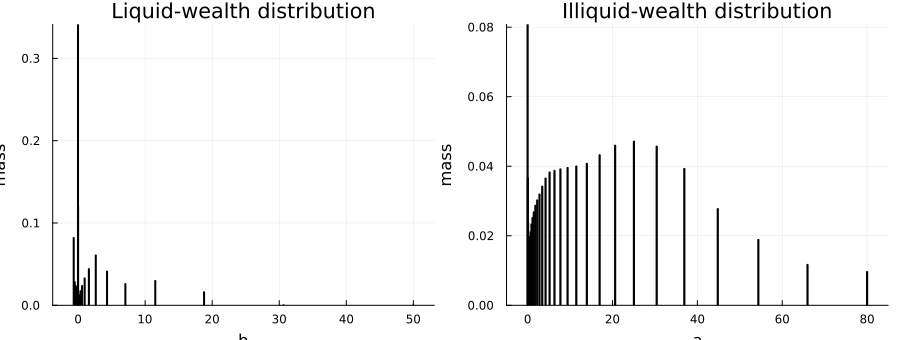

In [10]:
marginal_b = vec(sum(h.D, dims=(1,3)))
marginal_a = vec(sum(h.D, dims=(1,2)))
p_db = bar(grids.b, marginal_b, xlabel="b", ylabel="mass", title="Liquid-wealth distribution", legend=false)
p_da = bar(grids.a, marginal_a, xlabel="a", ylabel="mass", title="Illiquid-wealth distribution", legend=false)
plot(p_db, p_da, layout=(1,2), size=(900,340))

## 7) Transition-Block Implementation

For a candidate household-input path

$$
X=(R^b,R^a,w,T,\tau),
$$

the household transition block performs two passes.

### 7.1 Backward policy pass

Start from the stationary terminal marginal values

$$
(V_{b,T},V_{a,T})=(V_{b,ss},V_{a,ss})
$$

and apply the two-asset EGM step for $t=T-1,\ldots,0$. This produces

$$
\{b_{t+1}(e,b,a),a_{t+1}(e,b,a),c_t(e,b,a),n_t(e,b,a)\}_{t=0}^{T-1}.
$$

### 7.2 Forward distribution pass

Start from $D_0=D_{ss}$. At each date, aggregate current policies under $D_t$
and then transport mass using the policy lotteries and earnings matrix:

$$
D_{t+1}=\mathcal T(g_t^b,g_t^a,P)D_t.
$$

The output paths are

$$
(B,A,C,H,N,\Chi),
$$

together with $D_T$. The terminal distribution is an output and is not forced
to equal $D_{ss}$.

### 7.3 Reduced equilibrium map

The full transition evaluator composes

$$
(U,E)
\longmapsto(R^b,R^a,w,T,\tau)
\longmapsto(B,A,C,N,\Chi)
\longmapsto H(U;E).
$$

This is the nonlinear map that is differentiated by SSJ.

## 8) Household Partial-Equilibrium Jacobians

The household sequence-space mapping is

$$
(R^b,R^a,w,T,\tau)\longmapsto(B,A,C,N,\Chi),
$$

with blocks

$$
J_{t,s}^{o,x}=\frac{\partial o_t}{\partial x_s}.
$$

We now construct these blocks with the two-asset **Fake News Algorithm**. For
each input $x$, a single perturbation at the end of a stationary path and one
backward pass generate the policy response to news at every horizon. Bilinear
lotteries on $(b,a)$ give the one-step distribution news. Steady-state
expectation vectors propagate that news forward, and diagonal recursion recovers
the full Jacobian. Hence the expensive operation scales with the number of
horizons rather than rerunning a complete transition for every dated input.

A short $T=6$ brute-force calculation remains below solely as a numerical
validation. The production Jacobian uses $T_J=120$.

In [11]:
T_check = 6
naive_check_seconds = @elapsed naive_check = kmv_household_jacobian(ss, T_check; h=2e-5)
fake_check_seconds = @elapsed fake_check = kmv_household_fake_news_jacobian(ss, T_check; h=2e-5)
fake_news_error = maximum(abs.(naive_check.J .- fake_check.J))

T_J = 120
hhJ_seconds = @elapsed hhJ = kmv_household_fake_news_jacobian(ss, T_J; h=2e-5)
(method=hhJ.method, size=size(hhJ.J), seconds=hhJ_seconds,
 short_horizon_error=fake_news_error,
 short_naive_seconds=naive_check_seconds, short_fake_seconds=fake_check_seconds,
 finite=all(isfinite, hhJ.J))

(method = :fake_news, size = (600, 600), seconds = 17.3187698, short_horizon_error = 0.00013760528297623864, short_naive_seconds = 5.648342, short_fake_seconds = 2.3492257, finite = true)

### 8.1 Direct liquid-rate consumption response

The block $J_{C,R^b}$ maps a liquid-return path into consumption while holding
$R^a$, wages, transfers, and taxes fixed. Thus

$$
dC^{direct}=J_{C,R^b}\,dR^b
$$

is the partial-equilibrium/direct interest-rate channel.

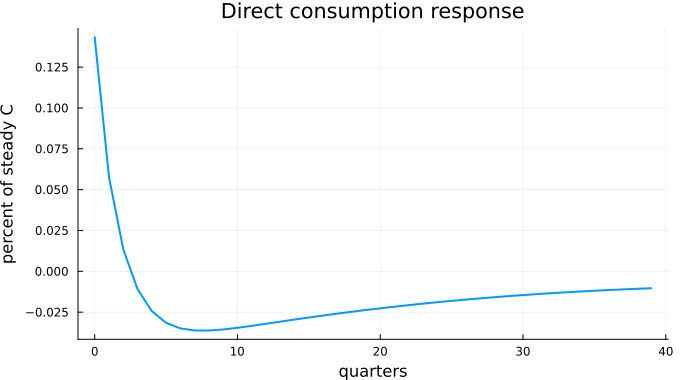

In [12]:
J_C_Rb = hhJ.J[2*T_J+1:3*T_J, 1:T_J]
direct_rate_path = -0.0025 .* 0.6 .^ (0:T_J-1)
direct_C = J_C_Rb * direct_rate_path
direct_plot_horizon = 40
direct_periods = 0:direct_plot_horizon-1
plot(direct_periods, 100 .* direct_C[1:direct_plot_horizon] ./ h.C, xlabel="quarters",
     ylabel="percent of steady C", title="Direct consumption response", legend=false)

## 9) Compose the General-Equilibrium Jacobian

Let $X=(R^b,R^a,w,T,\tau)$ collect household inputs and let
$O=(B,A,C,N,\Chi)$ collect household outputs. The macro blocks provide
$X_U$ and $X_E$, while Fake News provides $J^{O,X}$. The household contribution
to equilibrium derivatives is therefore

$$
J^{O,U}=J^{O,X}X_U,\qquad J^{O,E}=J^{O,X}X_E.
$$

Adding the direct NKPC, capital, labor-demand, and equity derivatives gives

$$
dH=H_UdU+H_EdE=0,\qquad
G^{U,E}=-H_U^{-1}H_E.
$$

`solve_kmv_ge_jacobian` now performs this block composition and reuses `hhJ`;
it no longer finite-differences the complete household transition for every
column of $H_U$ and $H_E$. The old full finite-difference routine remains in
the function file under `solve_kmv_ge_jacobian_bruteforce` for short validation
only.

In [13]:
T_GE = 120
ge_seconds = @elapsed ge = solve_kmv_ge_jacobian(
    ss, T_GE; household_J=hhJ, hU=2e-5, hE=2e-5
)
(method=ge.method, seconds=ge_seconds, HU=size(ge.HU), HE=size(ge.HE),
 steady_residual=maximum(abs.(ge.steady_residual)),
 condition_number=cond(ge.HU))

(method = :fake_news_block_composition, seconds = 1.4833433, HU = (600, 600), HE = (600, 240), steady_residual = 0.0, condition_number = 430015.1843120604)

## 10) Linear Monetary-Policy Impulse Responses

Consider an expansionary 25-basis-point innovation to the Taylor rule,

$$
d\eta_t=-0.0025\times0.6^t.
$$

The GE Jacobian gives $dU=G^{U,E}dE$. The transition evaluator then maps the
solved unknown paths into household and macro responses. Following the display
convention in `HANK.ipynb`, the model is solved for 120 quarters and the figure
displays the first 40. This pushes the finite-horizon terminal condition well
beyond the plotted window. Responses are drawn as continuous lines without
point markers. Output and consumption are percent deviations from steady state;
inflation and the real liquid rate are annualized percentage points.

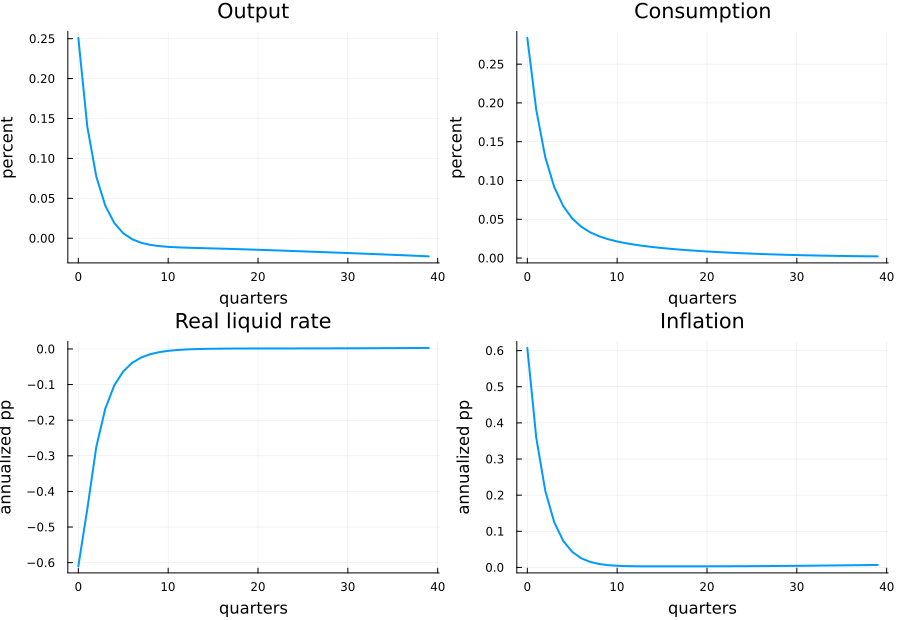

In [14]:
irf = kmv_monetary_irf(ss, ge; shock=-0.0025, rho=0.6)
irf_plot_horizon = 40
quarters = 0:irf_plot_horizon-1
shown = 1:irf_plot_horizon
pY = plot(quarters, 100 .* irf.Y[shown] ./ m.Y, title="Output", ylabel="percent", legend=false)
pC = plot(quarters, 100 .* irf.C[shown] ./ h.C, title="Consumption", ylabel="percent", legend=false)
pR = plot(quarters, 400 .* irf.Rb[shown], title="Real liquid rate", ylabel="annualized pp", legend=false)
pPi = plot(quarters, 400 .* irf.pi[shown], title="Inflation", ylabel="annualized pp", legend=false)
plot(pY, pC, pR, pPi, layout=(2,2), size=(900,620), xlabel="quarters")

## 11) Numerical and Economic Checks

A smooth policy plot is not a correctness test. This section checks the
household first-order conditions, grid robustness, probability accounting, and
aggregate equilibrium independently of the objects used as solver targets.

### 11.1 Budget, Euler, and Kuhn-Tucker residuals

For interior liquid choices, the code checks

$$
u_c=\beta E[V_b'].
$$

For interior illiquid choices, it checks

$$
u_c(1+\Psi_1)=\beta E[V_a'].
$$

At the liquid borrowing limit, it checks the corresponding inequality. Euler
errors are reported as distribution-weighted log residuals; the budget error is
reported in levels.

In [15]:
policy_checks = kmv_household_residuals(ss)
pc = policy_checks.summary

println("11.1 Household optimality and budget diagnostics")
println(repeat("-", 100))
@printf("%-42s %14s %18s %10s\n", "diagnostic", "value", "reference tolerance", "status")
println(repeat("-", 100))
residual_rows = [
    ("Maximum budget error", pc.maximum_budget_error, 1e-10, :less),
    ("Liquid Euler weighted RMSE", pc.liquid_euler_weighted_rmse, 5e-3, :less),
    ("Liquid Euler maximum", pc.liquid_euler_maximum, 5e-2, :less),
    ("Liquid KKT maximum violation", pc.liquid_kkt_maximum, 5e-2, :less),
    ("Illiquid Euler weighted RMSE", pc.illiquid_euler_weighted_rmse, 5e-3, :less),
    ("Illiquid Euler maximum", pc.illiquid_euler_maximum, 5e-2, :less),
    ("Mass at top liquid-policy boundary", pc.top_liquid_policy_mass, 1e-2, :less),
    ("Mass at top illiquid-policy boundary", pc.top_illiquid_policy_mass, 1e-2, :less),
]
for (label, value, tolerance, _) in residual_rows
    @printf("%-42s %14.6e %18.1e %10s\n",
        label, value, tolerance, value < tolerance ? "PASS" : "CHECK")
end
println(repeat("-", 100))
@printf("%-42s %13.3f%%\n", "Distribution mass with interior liquid choice", 100 * pc.liquid_interior_mass)
@printf("%-42s %13.3f%%\n", "Distribution mass with interior illiquid choice", 100 * pc.illiquid_interior_mass)
println("RMSE values are stationary-distribution weighted; maxima are worst-state diagnostics.")

11.1 Household optimality and budget diagnostics
----------------------------------------------------------------------------------------------------
diagnostic                                          value reference tolerance     status
----------------------------------------------------------------------------------------------------


Maximum budget error                         2.842171e-14            1.0e-10       PASS
Liquid Euler weighted RMSE                   6.516614e-04            5.0e-03       PASS
Liquid Euler maximum                         1.177998e-02            5.0e-02       PASS
Liquid KKT maximum violation                 1.177998e-02            5.0e-02       PASS
Illiquid Euler weighted RMSE                 1.780697e-03            5.0e-03       PASS
Illiquid Euler maximum                       2.758869e-02            5.0e-02       PASS
Mass at top liquid-policy boundary           0.000000e+00            1.0e-02       PASS
Mass at top illiquid-policy boundary         4.705863e-03            1.0e-02       PASS
----------------------------------------------------------------------------------------------------
Distribution mass with interior liquid choice        92.391%
Distribution mass with interior illiquid choice        94.204%
RMSE values are stationary-distribution weighted; maxima are worst-stat

### 11.2 Jacobian, equilibrium, and Walras-law checks

This cell reports the Fake News validation error, computation times, the
solved-target error, equity-pricing error, and the goods-market residual,
which was not used as an additional GE target.

In [16]:
checks = (
    jacobian_method=ge.method,
    fake_news_validation_error=fake_news_error,
    household_jacobian_seconds=hhJ_seconds,
    ge_composition_seconds=ge_seconds,
    steady_target_error=maximum(abs.(ge.steady_residual)),
    linear_goods_error=maximum(abs.(irf.goods)),
    distribution_mass=sum(h.D),
    equity_steady_error=abs(m.equity_residual)
)

println("11.2 Jacobian, equilibrium, and Walras-law diagnostics")
println(repeat("-", 100))
@printf("%-42s %20s\n", "Jacobian construction method", string(checks.jacobian_method))
@printf("%-42s %19.3f s\n", "Household Jacobian time", checks.household_jacobian_seconds)
@printf("%-42s %19.3f s\n", "GE block-composition time", checks.ge_composition_seconds)
println(repeat("-", 100))
@printf("%-42s %14s %18s %10s\n", "diagnostic", "value", "reference tolerance", "status")
println(repeat("-", 100))
check_rows = [
    ("Fake-news vs brute-force Jacobian error", checks.fake_news_validation_error, 5e-4),
    ("Steady-state target residual", checks.steady_target_error, 1e-8),
    ("Linearized goods-market residual", checks.linear_goods_error, 1e-4),
    ("Stationary-distribution mass error", abs(checks.distribution_mass - 1), 1e-10),
    ("Steady-state equity-pricing error", checks.equity_steady_error, 1e-10),
]
for (label, value, tolerance) in check_rows
    @printf("%-42s %14.6e %18.1e %10s\n",
        label, value, tolerance, value < tolerance ? "PASS" : "CHECK")
end
println(repeat("-", 100))
println("The goods-market residual is a Walras-law check; it was not one of the five GE solver targets.")

11.2 Jacobian, equilibrium, and Walras-law diagnostics
----------------------------------------------------------------------------------------------------
Jacobian construction method               fake_news_block_composition
Household Jacobian time                                 17.319 s
GE block-composition time                                1.483 s
----------------------------------------------------------------------------------------------------
diagnostic                                          value reference tolerance     status
----------------------------------------------------------------------------------------------------
Fake-news vs brute-force Jacobian error      1.376053e-04            5.0e-04       PASS


Steady-state target residual                 0.000000e+00            1.0e-08       PASS
Linearized goods-market residual             1.349259e-05            1.0e-04       PASS
Stationary-distribution mass error           0.000000e+00            1.0e-10       PASS
Steady-state equity-pricing error            9.714451e-17            1.0e-10       PASS
----------------------------------------------------------------------------------------------------
The goods-market residual is a Walras-law check; it was not one of the five GE solver targets.


## 12) MPC, Hand-to-Mouth Households, and Data Moments

### 12.1 Finite-transfer MPC experiment

We follow the calculation in the one-asset HANK notebook, but propagate both
liquid and illiquid choices. The date-zero transfer is normalized to 3 percent
of mean quarterly labor income,

$$
x=0.03\,\bar y^{\ell},\qquad
\bar y^{\ell}=\sum_{e,b,a}D_{ss}(e,b,a)w_{ss}e n_{ss}(e,b,a).
$$

The continuation marginal values are held fixed in the impact period. After
the initial policy response, households follow the stationary two-asset policy.
For horizon $H$ quarters,

$$
\operatorname{MPC}_{H}(e,b,a)
=\frac{\mathcal C_H^x(e,b,a)-\mathcal C_H^0(e,b,a)}{x},
\qquad
\overline{\operatorname{MPC}}_H
=\sum_{e,b,a}D_{ss}(e,b,a)\operatorname{MPC}_H(e,b,a).
$$

The cumulative-consumption recursion integrates the earnings transition and
the interpolation lotteries for both $b'$ and $a'$.

In [17]:
micro = kmv_mpc_statistics(ss; transfer_share=0.03, horizons=(1, 2, 4))

println("Transfer normalization and cumulative MPCs")
println(repeat("-", 104))
@printf("Mean quarterly labor income (model units)    %10.6f\n", micro.mean_labor_income)
@printf("One-time transfer (model units)             %10.6f\n", micro.transfer)
@printf("Transfer / mean quarterly labor income      %9.3f%%\n", 100micro.transfer_share)
@printf("Baseline policy replay error                %10.3e\n", micro.replay_error)
println()
println(" horizon       mean     median        p90   share MPC>=0.5   poor HtM   wealthy HtM   non-HtM")
for horizon in (1, 2, 4)
    stat = micro.horizon_statistics[horizon]
    @printf(" %3d qtrs   %8.4f   %8.4f   %8.4f       %8.3f%%    %8.4f      %8.4f    %8.4f\n",
        horizon, stat.mean, stat.median, stat.p90, 100stat.high_mpc_share,
        stat.poor_htm_mean, stat.wealthy_htm_mean, stat.non_htm_mean)
end

Transfer normalization and cumulative MPCs
--------------------------------------------------------------------------------------------------------
Mean quarterly labor income (model units)      0.655973
One-time transfer (model units)               0.019679
Transfer / mean quarterly labor income          3.000%
Baseline policy replay error                 2.325e-07

 horizon       mean     median        p90   share MPC>=0.5   poor HtM   wealthy HtM   non-HtM
   1 qtrs     0.1009     0.0916     0.2073          0.000%      0.2227        0.1373      0.0954


   2 qtrs     0.1450     0.1210     0.2725          0.000%      0.3710        0.1817      0.1389
   4 qtrs     0.2059     0.1741     0.3841          2.904%      0.4826        0.2252      0.2019


### 12.2 KMV hand-to-mouth definitions

KMV's model targets use the exact endogenous kinks $b=0$ and $b<0$:

$$
\text{poor HtM}: b=0,\ a=0,\qquad
\text{wealthy HtM}: b=0,\ a>0.
$$

In survey data, KMV implement these concepts with a $\pm\$1{,}000$ window
because wealth is measured with error. Since their $\$16{,}500$ borrowing limit
is approximately one quarter of labor income, we additionally report the
data-mapping sensitivity $|b|\leq\bar y^{\ell}/16.5$. Calibration below uses
the exact model definitions; the dollar-band statistics are diagnostics only.

In [18]:
impact = micro.horizon_statistics[1]

println("KMV-style hand-to-mouth statistics")
println(repeat("-", 76))
@printf("Exact-model poor HtM share                       %9.3f%%\n", 100micro.poor_htm_share)
@printf("Exact-model wealthy HtM share                    %9.3f%%\n", 100micro.wealthy_htm_share)
@printf("Total HtM share                                  %9.3f%%\n", 100micro.total_htm_share)
@printf("Wealthy households / all HtM                     %9.3f%%\n", 100micro.wealthy_share_of_htm)
@printf("Exact-model negative-liquid-wealth share         %9.3f%%\n", 100micro.negative_liquid_share)
println()
@printf("Data-mapping liquid band                    +/- %9.6f\n", micro.liquid_band)
@printf("Band poor / wealthy HtM shares              %8.3f%% / %8.3f%%\n",
    100micro.band_poor_htm_share, 100micro.band_wealthy_htm_share)
@printf("Share below the lower edge of the band            %9.3f%%\n",
    100micro.band_negative_liquid_share)
@printf("HtM share of aggregate consumption               %9.3f%%\n", 100micro.htm_consumption_share)
@printf("HtM share of aggregate net wealth                %9.3f%%\n", 100micro.htm_wealth_share)
println()
@printf("Impact MPC: aggregate / poor / wealthy / non-HtM = %.4f / %.4f / %.4f / %.4f\n",
    impact.mean, impact.poor_htm_mean, impact.wealthy_htm_mean, impact.non_htm_mean)

KMV-style hand-to-mouth statistics
----------------------------------------------------------------------------
Exact-model poor HtM share                           0.496%
Exact-model wealthy HtM share                       11.549%
Total HtM share                                     12.045%
Wealthy households / all HtM                        95.883%
Exact-model negative-liquid-wealth share            55.346%

Data-mapping liquid band                    +/-  0.039756
Band poor / wealthy HtM shares                 0.992% /   46.158%
Share below the lower edge of the band               21.210%
HtM share of aggregate consumption                  12.962%
HtM share of aggregate net wealth                   17.945%

Impact MPC: aggregate / poor / wealthy / non-HtM = 0.1009 / 0.2227 / 0.1373 / 0.0954


### 12.3 Current model and KMV model moments

The comparison below uses the same observable definitions as KMV whenever the
current discrete-time, no-death model permits it. Each row reports only the
current model value and the corresponding value in KMV's calibrated model.

Mean asset stocks are divided by annual output, $4Y$, because this notebook is
quarterly. The first five rows correspond to KMV Table 5; the remaining rows
report HtM consumption and wealth shares and the one-quarter MPC.

In [19]:
moment_comparison = kmv_data_moment_comparison(ss, micro)

println("Current discrete-time model versus KMV model")
println(repeat("-", 76))
@printf("%-41s %15s %15s\n", "moment", "current model", "KMV model")
println(repeat("-", 76))
for row in moment_comparison
    @printf("%-41s %15.4f %15.4f\n",
        row.moment, row.current_model, row.paper_model)
end
println(repeat("-", 76))

Current discrete-time model versus KMV model
----------------------------------------------------------------------------
moment                                      current model       KMV model
----------------------------------------------------------------------------
Mean illiquid assets / annual output               3.0636          2.9200
Mean liquid assets / annual output                 0.2991          0.2300
Poor HtM share                                     0.0050          0.1000
Wealthy HtM share                                  0.1155          0.1900
Negative-liquid-wealth share                       0.5535          0.1500
HtM consumption share                              0.1296          0.2000
HtM wealth share                                   0.1794          0.0250
One-quarter MPC                                    0.1009          0.1600
----------------------------------------------------------------------------


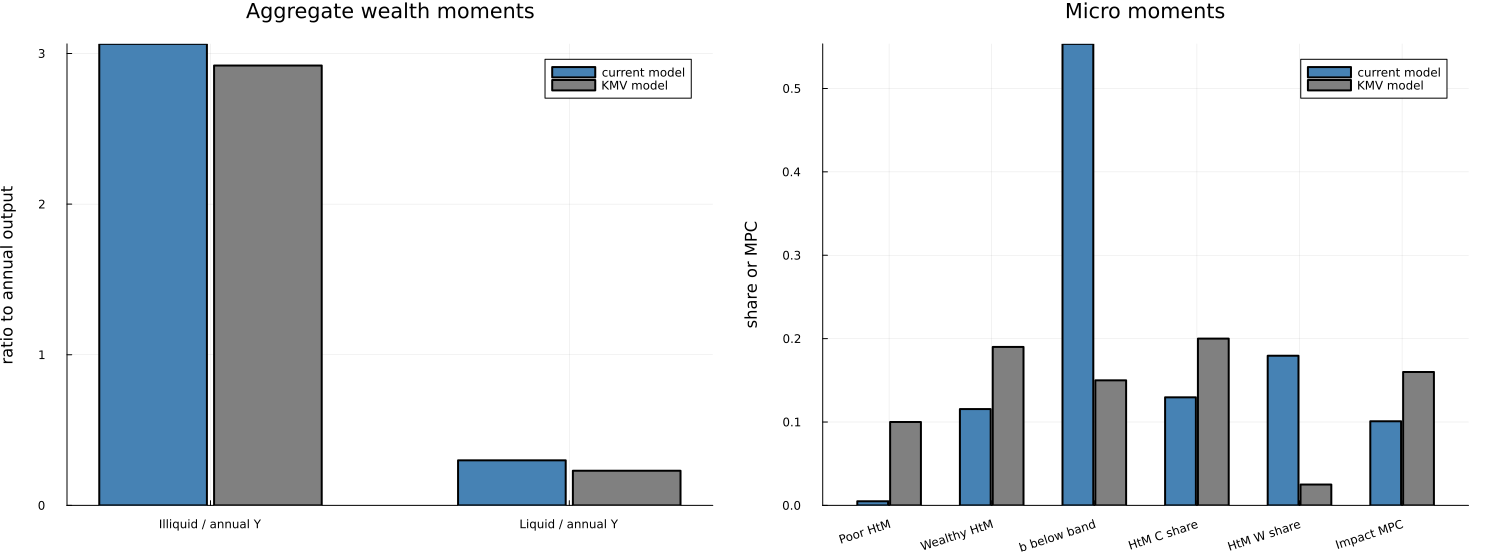

In [20]:
wealth_rows = moment_comparison[1:2]
micro_rows = moment_comparison[3:end]

wealth_labels = ["Illiquid / annual Y", "Liquid / annual Y"]
wealth_x = collect(eachindex(wealth_labels))
wealth_model = getproperty.(wealth_rows, :current_model)
wealth_paper = getproperty.(wealth_rows, :paper_model)
p_wealth_match = bar(wealth_x .- 0.16, wealth_model;
    bar_width=0.30, label="current model", color=:steelblue,
    title="Aggregate wealth moments", ylabel="ratio to annual output",
    xticks=(wealth_x, wealth_labels), legend=:topright)
bar!(p_wealth_match, wealth_x .+ 0.16, wealth_paper;
    bar_width=0.30, label="KMV model", color=:gray)

micro_labels = ["Poor HtM", "Wealthy HtM", "b below band", "HtM C share", "HtM W share", "Impact MPC"]
micro_x = collect(eachindex(micro_labels))
micro_model = getproperty.(micro_rows, :current_model)
micro_paper = getproperty.(micro_rows, :paper_model)
p_micro_match = bar(micro_x .- 0.16, micro_model;
    bar_width=0.30, label="current model", color=:steelblue,
    title="Micro moments", ylabel="share or MPC",
    xticks=(micro_x, micro_labels), xrotation=18, legend=:topright)
bar!(p_micro_match, micro_x .+ 0.16, micro_paper;
    bar_width=0.30, label="KMV model", color=:gray)

plot(p_wealth_match, p_micro_match; layout=(1, 2), size=(1500, 560), margin=6Plots.mm)

**Interpretation.** The main mismatches are the poor HtM share, the share of households with negative liquid wealth, the one-quarter MPC, and the HtM wealth share.

The current model produces a poor HtM share of 0.5 percent, far below KMV's 10 percent, and a one-quarter MPC of 10.1 percent, below the KMV model's 16 percent. By contrast, 55.3 percent of households hold negative liquid wealth, compared with 15 percent in KMV. The HtM wealth share is 17.9 percent, versus 2.5 percent in the KMV model and 4.4 percent in the data.

These discrepancies motivate the selected-parameter calibration in Section 13, where we examine how far the discrete-time, no-death model can move toward the KMV targets.

## 13) Calibration and External Validation

### 13.1 Calibrated parameters and target moments

We calibrate five household parameters while retaining the notebook's
discrete-time, no-death structure:

| parameter | selected value | role in the calibration |
|---|---:|---|
| $\beta$ | $0.98145$ | overall household saving, especially illiquid wealth |
| $\kappa_b$ | $0.0200$ | cost of unsecured borrowing and the mass with $b<0$ |
| $\chi_0$ | $0.0200$ | linear adjustment wedge and the mass in the inaction region |
| $\chi_1$ | $0.3400$ | scale of convex illiquid adjustment costs |
| $\chi_2$ | $1.4020$ | curvature of convex illiquid adjustment costs |

The five target moments are

$$
\frac{A}{4Y}=2.92,\qquad
\frac{B}{4Y}=0.26,\qquad
\Pr(b=0,a=0)=0.10,\qquad
\Pr(b=0,a>0)=0.20,\qquad
\Pr(b<0)=0.15.
$$

These are data targets, not the moments mechanically delivered by the selected
parameters. Model HtM moments use the exact $b=0$ atoms. The empirical measures use
the $\pm\$1,000$ measurement window described in KMV's footnote 37. The
cells below report only the selected parameter values and their moment fit.

In [21]:
calibration_targets = (
    illiquid_to_annual_output=2.92,
    liquid_to_annual_output=0.26,
    poor_htm_share=0.10,
    wealthy_htm_share=0.20,
    negative_liquid_share=0.15,
)
selected_calibration = (
    beta=0.98145,
    borrowing_wedge=0.0200,
    chi0=0.0200,
    chi1=0.3400,
    chi2=1.4020,
)

calibrated_params = KMVDiscrete.kmv_replace_parameters(
    params;
    beta=selected_calibration.beta,
    borrowing_wedge=selected_calibration.borrowing_wedge,
    chi0=selected_calibration.chi0,
    chi1=selected_calibration.chi1,
    chi2=selected_calibration.chi2,
);

In [22]:
ss_calibrated = calibrate_kmv_steady_state(
    calibrated_params, macro_params;
    Rb=1.005, Ra=1.01425, w=1.05, T=0.10,
    backward_tol=6e-6, forward_tol=5e-9, damp=0.8,
)
calibrated_moments = kmv_calibration_moments(
    ss_calibrated; annual_output=4ss_calibrated.macro_ss.Y)
micro_calibrated = kmv_mpc_statistics(
    ss_calibrated; transfer_share=0.03, horizons=(1, 2, 4))

calibration_fit = [
    (moment="Illiquid assets / annual output",
     model=calibrated_moments.illiquid_to_annual_output,
     target=calibration_targets.illiquid_to_annual_output),
    (moment="Liquid assets / annual output",
     model=calibrated_moments.liquid_to_annual_output,
     target=calibration_targets.liquid_to_annual_output),
    (moment="Poor HtM: Pr(b=0,a=0)",
     model=calibrated_moments.poor_htm_share,
     target=calibration_targets.poor_htm_share),
    (moment="Wealthy HtM: Pr(b=0,a>0)",
     model=calibrated_moments.wealthy_htm_share,
     target=calibration_targets.wealthy_htm_share),
    (moment="Negative-liquid-wealth share",
     model=calibrated_moments.negative_liquid_share,
     target=calibration_targets.negative_liquid_share),
]

println("Calibration fit")
println(repeat("-", 66))
@printf("%-38s %12s %12s\n", "target moment", "model", "data target")
println(repeat("-", 66))
for row in calibration_fit
    @printf("%-38s %12.4f %12.4f\n", row.moment, row.model, row.target)
end
println(repeat("-", 66))

Calibration fit
------------------------------------------------------------------
target moment                                 model  data target
------------------------------------------------------------------
Illiquid assets / annual output              2.9455       2.9200
Liquid assets / annual output                0.2696       0.2600
Poor HtM: Pr(b=0,a=0)                        0.0066       0.1000
Wealthy HtM: Pr(b=0,a>0)                     0.2288       0.2000
Negative-liquid-wealth share                 0.4437       0.1500
------------------------------------------------------------------


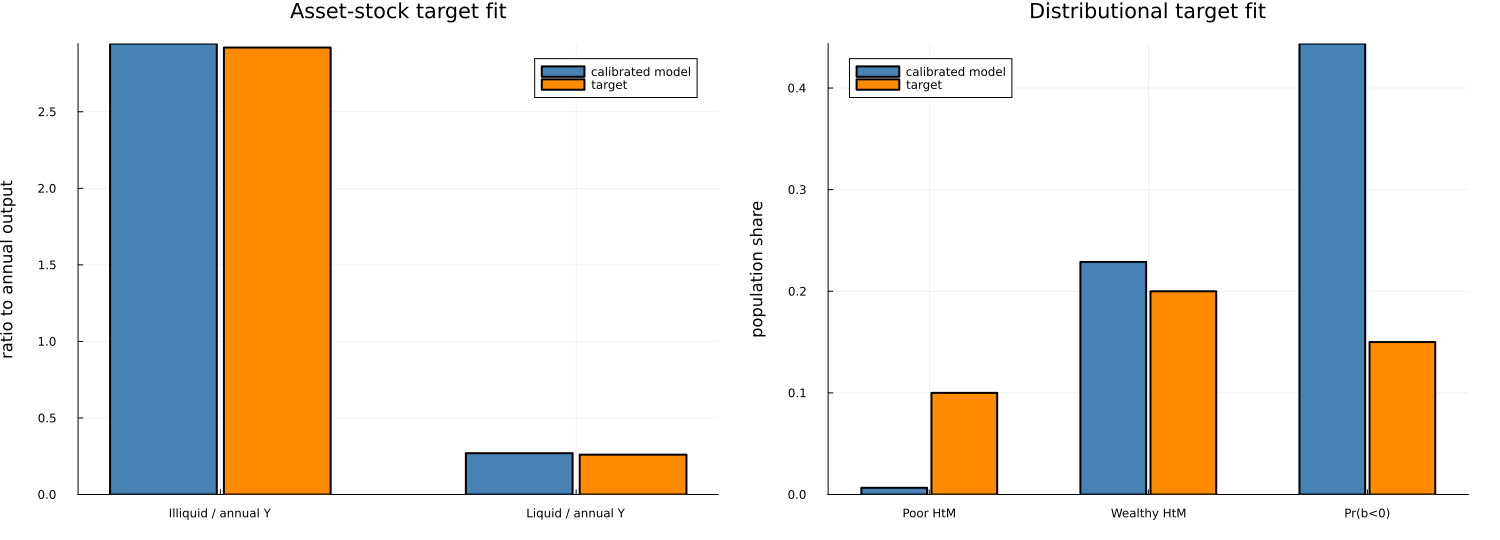

In [23]:
asset_labels = ["Illiquid / annual Y", "Liquid / annual Y"]
share_labels = ["Poor HtM", "Wealthy HtM", "Pr(b<0)"]
asset_x, share_x = 1:2, 1:3
p_calibration_assets = bar(
    collect(asset_x) .- 0.16, getproperty.(calibration_fit[1:2], :model);
    bar_width=0.30, color=:steelblue, label="calibrated model",
    xticks=(asset_x, asset_labels), ylabel="ratio to annual output",
    title="Asset-stock target fit",
)
bar!(p_calibration_assets, collect(asset_x) .+ 0.16,
    getproperty.(calibration_fit[1:2], :target);
    bar_width=0.30, color=:darkorange, label="target")
p_calibration_shares = bar(
    collect(share_x) .- 0.16, getproperty.(calibration_fit[3:5], :model);
    bar_width=0.30, color=:steelblue, label="calibrated model",
    xticks=(share_x, share_labels), ylabel="population share",
    title="Distributional target fit",
)
bar!(p_calibration_shares, collect(share_x) .+ 0.16,
    getproperty.(calibration_fit[3:5], :target);
    bar_width=0.30, color=:darkorange, label="target")
plot(p_calibration_assets, p_calibration_shares;
    layout=(1, 2), size=(1500, 540), margin=6Plots.mm)

### 13.2 External validation

The following three moments are not among the five calibration targets:

- one-quarter MPC: empirical range 15--25 percent;
- HtM shares of consumption and wealth: 25 percent and 4.4 percent.

They therefore provide an external validation of the calibrated model.

In [24]:
validation_rows = [
    (moment="One-quarter MPC", model=micro_calibrated.horizon_statistics[1].mean,
     data_low=0.15, data_high=0.25),
    (moment="HtM consumption share", model=micro_calibrated.htm_consumption_share,
     data_low=0.25, data_high=0.25),
    (moment="HtM wealth share", model=micro_calibrated.htm_wealth_share,
     data_low=0.044, data_high=0.044),
]

println("External validation: none of these moments was targeted")
println(repeat("-", 78))
@printf("%-30s %12s %20s\n", "moment", "model", "data target/range")
for row in validation_rows
    target = row.data_low == row.data_high ?
        @sprintf("%.4f", row.data_low) : @sprintf("[%.4f, %.4f]", row.data_low, row.data_high)
    @printf("%-30s %12.4f %20s\n", row.moment, row.model, target)
end
println(repeat("-", 78))

External validation: none of these moments was targeted
------------------------------------------------------------------------------
moment                                model    data target/range


One-quarter MPC                      0.1059     [0.1500, 0.2500]
HtM consumption share                0.2280               0.2500
HtM wealth share                     0.2839               0.0440
------------------------------------------------------------------------------


**Interpretation.** After calibration, the poor HtM share remains much lower than the 10 percent target, while the share of households with negative liquid wealth remains much higher than the 15 percent target.

For external validation, the one-quarter MPC is 10.6 percent, below the empirical range of 15--25 percent. The HtM consumption share, 22.8 percent, is fairly close to the 25 percent target, but the HtM wealth share, 28.4 percent, remains much higher than the empirical 4.4 percent.

Part of these remaining gaps reflects model structure. Unlike KMV, this notebook excludes mortality and newborn replacement, a mechanism that continuously introduces zero-wealth households and can be important for the poor HtM mass. The model also uses a simple discrete AR(1) earnings process, whereas KMV use a richer empirically estimated continuous-time earnings process with persistent and transitory movements and infrequent jumps.

## 14) Consumption-Channel Decomposition

Consider the same expansionary monetary-policy innovation used above,

$$
d\eta_t=-0.0025\times0.6^t.
$$

This section uses the calibrated steady state from Section 13. General
equilibrium first determines the five household-input paths
$(dR^b,dR^a,dw,dT,d\tau)$. The two-asset household Jacobians then imply

$$
dC=
\underbrace{J_{C,R^b}dR^b}_{\text{direct effect}}
+\underbrace{J_{C,R^a}dR^a+J_{C,w}dw+J_{C,T}dT
+J_{C,\tau}d\tau}_{\text{indirect general-equilibrium effects}}.
$$

Following Kaplan, Moll, and Violante (2018), only the liquid-return term is
classified as direct: it varies $R^b$ while holding disposable labor income
and all other household inputs fixed. The illiquid-return/equity-value, wage,
transfer, and tax paths are equilibrium outcomes and are therefore indirect.
In this discrete implementation $q$ is not a separate household input; its
equilibrium movement is shown with the price paths, while the household
consumption contribution is carried by $dR^a$. The baseline fiscal rule keeps
$\tau$ fixed, so its channel is zero. At first order all components must add
exactly to the total consumption IRF.

As in KMV Table 7, the summary reports both the impact response and the average
response over the first four quarters.

In [26]:
T_channels = T_GE
hhJ_channels = kmv_household_fake_news_jacobian(
    ss_calibrated, T_channels; h=2e-5
)
ge_channels = solve_kmv_ge_jacobian(
    ss_calibrated, T_channels; household_J=hhJ_channels, hU=2e-5, hE=2e-5
)
channel_shock = zeros(2T_channels)
channel_shock[T_channels+1:2T_channels] .= -0.0025 .* 0.6 .^ (0:T_channels-1)
consumption_channels = kmv_consumption_channel_decomposition(
    ss_calibrated, ge_channels, channel_shock
)
consumption_channels.closure_error < 1e-10 ||
    error("Consumption channels do not add up")
channel_summary = print_kmv_consumption_channel_summary(
    consumption_channels, ss_calibrated;
    label="calibrated-model monetary easing", first_year=4
);

Consumption-channel decomposition: calibrated-model monetary easing
--------------------------------------------------------------------------------------------
channel                            impact (% of C) first-year avg (% of C) share of first year
--------------------------------------------------------------------------------------------
Direct: liquid return Rb                  0.10799%             0.03995%            22.64%
Indirect: illiquid return Ra/q           -0.01276%            -0.00397%            -2.25%
Indirect: wage                            0.09708%             0.07360%            41.71%
Indirect: transfer                        0.09713%             0.06688%            37.90%
Indirect: tax                             0.00000%             0.00000%             0.00%
All indirect                              0.18145%             0.13651%            77.36%
Total                                     0.28944%             0.17647%           100.00%
---------------------

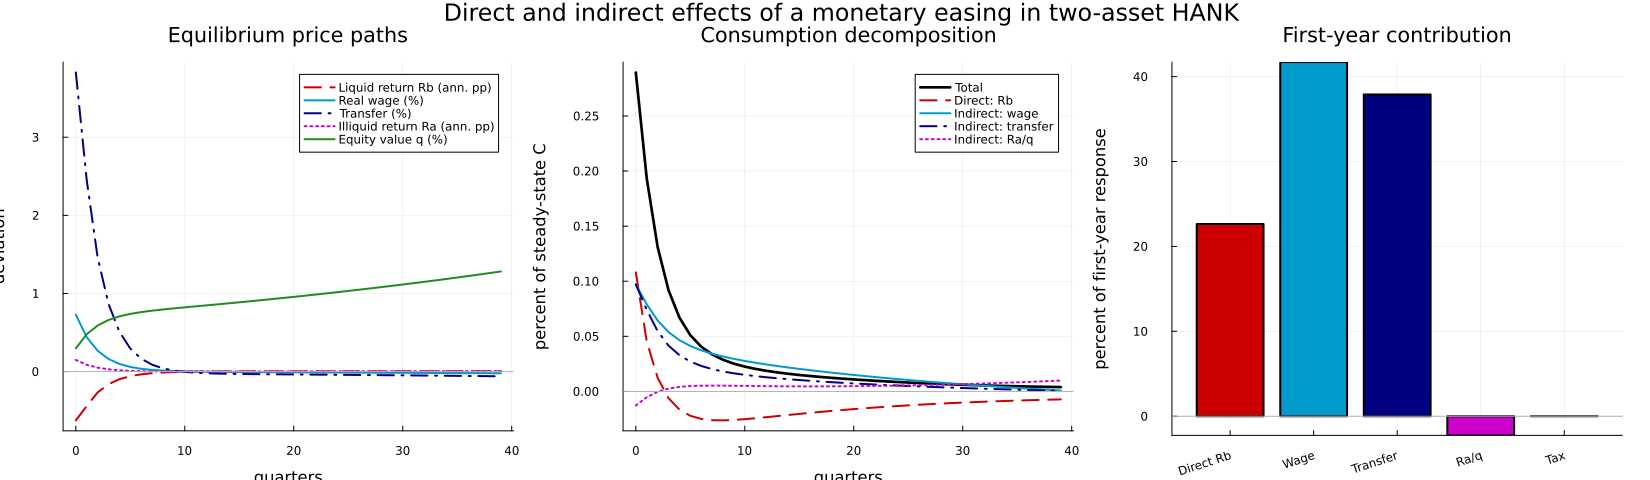

In [27]:
plot_kmv_consumption_channels(
    consumption_channels, ss_calibrated;
    horizon=40,
    title="Direct and indirect effects of a monetary easing in two-asset HANK",
)

### 14.1 Monetary easing: interpretation

For the calibrated discrete-time model, the first-year average consumption
response is $0.1765\%$ of steady-state consumption. The liquid-return direct
effect contributes $22.64\%$ of that response, while all indirect
general-equilibrium channels contribute $77.36\%$. Within the indirect
component, wages account for $41.71\%$, transfers for $37.90\%$, and the
illiquid-return/equity-value channel for $-2.25\%$; the fixed tax rule makes
the tax contribution zero.

The economic mechanism is therefore not that households consume mainly
because the liquid real rate falls. Monetary easing raises labor demand and
labor income, and the government budget rule passes lower debt-service costs
through to transfers. Heterogeneous MPCs turn those income changes into a
large aggregate consumption response. The small negative $R^a/q$ term is the
portfolio-rebalancing force: a relatively more attractive illiquid account
redirects some resources away from current consumption.

These shares are a diagnostic of this notebook's discrete-time, no-death
calibration rather than a numerical replication of KMV Table 7. The close
qualitative result is the object of interest: indirect channels dominate,
and wages and transfers provide the largest contributions.


### 14.2 Positive TFP shock

We now apply the same decomposition to a one-standard-deviation positive
productivity shock, using the shock calibration in `HANK.ipynb` for direct
comparability:

$$
d\log Z_t=\sigma_Z\rho_Z^t,\qquad
\rho_Z=0.9,\qquad
\sigma_Z=0.07\sqrt{1-0.9^2}.
$$

TFP does not enter the household budget constraint as a separate input. It
first changes production, labor demand, marginal cost, asset returns, and the
government budget. General equilibrium therefore generates the five household
input paths $(dR^b,dR^a,dw,dT,d\tau)$, which are then passed through the
same household Jacobians as in Section 14.1. In the table below, `direct` means
the contribution of the liquid-return input to the household problem; it does
not mean that TFP itself enters household utility or the budget directly.


In [28]:
rho_tfp = 0.9
sigma_tfp = 0.07 * sqrt(1 - rho_tfp^2)
tfp_path = sigma_tfp .* rho_tfp .^ (0:T_channels-1)
tfp_channel_shock = vcat(tfp_path, zeros(T_channels))
tfp_consumption_channels = kmv_consumption_channel_decomposition(
    ss_calibrated, ge_channels, tfp_channel_shock
)
tfp_consumption_channels.closure_error < 1e-10 ||
    error("TFP consumption channels do not add up")
tfp_channel_summary = print_kmv_consumption_channel_summary(
    tfp_consumption_channels, ss_calibrated;
    label="positive one-sigma TFP shock", first_year=4
);

Consumption-channel decomposition: positive one-sigma TFP shock
--------------------------------------------------------------------------------------------
channel                            impact (% of C) first-year avg (% of C) share of first year
--------------------------------------------------------------------------------------------
Direct: liquid return Rb                  0.23978%             0.19916%            12.50%
Indirect: illiquid return Ra/q            0.14330%             0.18956%            11.90%
Indirect: wage                            0.82682%             0.82421%            51.75%
Indirect: transfer                        0.37659%             0.37985%            23.85%
Indirect: tax                             0.00000%             0.00000%             0.00%
All indirect                              1.34671%             1.39363%            87.50%
Total                                     1.58649%             1.59279%           100.00%
-------------------------

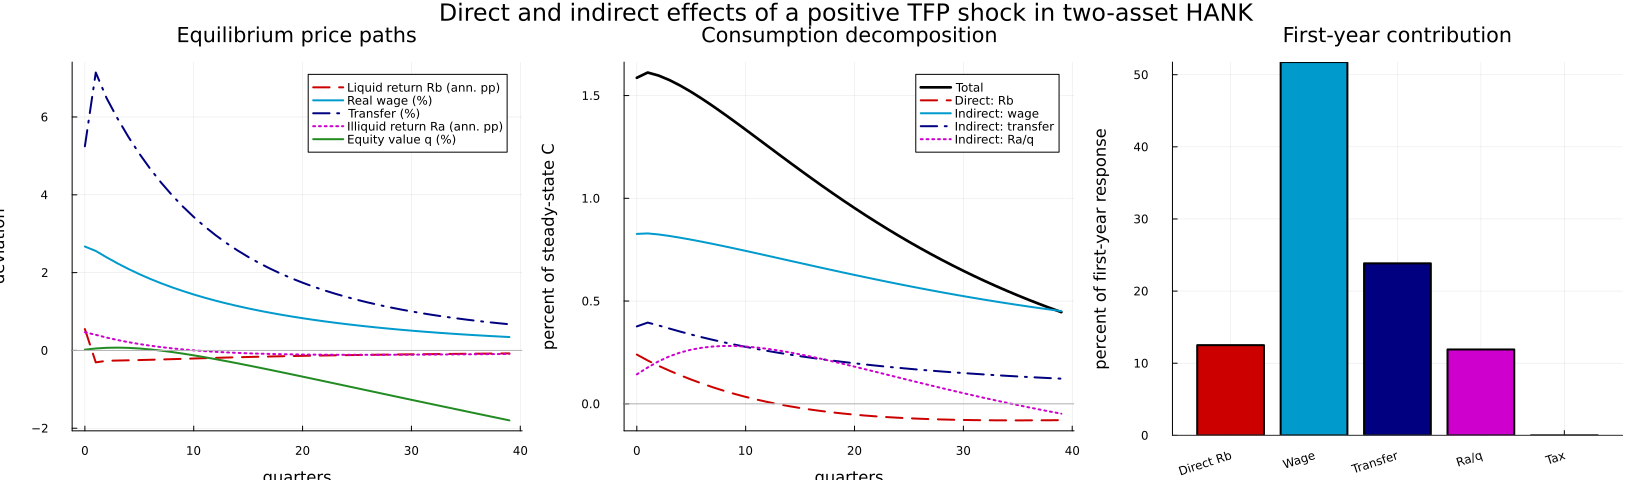

In [29]:
plot_kmv_consumption_channels(
    tfp_consumption_channels, ss_calibrated;
    horizon=40,
    title="Direct and indirect effects of a positive TFP shock in two-asset HANK",
)

**Interpretation.** The positive TFP shock raises first-year average
consumption by $1.59279\%$ of steady-state consumption. The liquid-return
channel contributes $12.50\%$ of the response. All indirect channels together
contribute $87.50\%$: wages account for $51.75\%$, transfers for $23.85\%$,
and the illiquid-return/equity-value block for $11.90\%$. The tax channel is
zero because the fiscal rule keeps $\tau$ fixed. The maximum adding-up error
is $8.7\times10^{-18}$.

The wage channel is the largest because higher productivity expands output and
changes firms' labor demand, producing a sizable equilibrium labor-income path.
Households with high MPCs translate that additional income into consumption.
The transfer channel is also positive because the expansion raises the labor-tax
base in the government budget rule. The two-asset model adds a further positive
portfolio contribution through the induced $R^a/q$ path. Finally, the positive
liquid-return contribution is the household response to the Fisher/Taylor-rule
path generated by TFP; it is not a primitive direct effect of productivity on
household utility or resources. Relative to Section 14.1, indirect channels are
even more dominant for the productivity shock.
